# IPN Cross-Correlation with Time-shifted GBM Lightcurves

This notebook demonstrates how to calculate an IPN localization using three GRB lightcurves from Fermi-GBM. In this tutorial, we will assume that each GBM lightcurve was observed by a different spacecraft and will input the relative time-shift ourselves.

As in `CCF_Example1.ipynb`, we will use the Gamma-ray Data Tools (GDT) to load in the GBM lightcurves, fit the background, define the spacecraft positions, perform the cross-correlation, find the time offsets, and create the localization skymap.

To get started, run the notebook cell below to load the data:

In [1]:
import warnings
warnings.filterwarnings("ignore")
from gdt.missions.fermi.gbm.tte import GbmTte

tte_n9 = GbmTte.open('data/glg_tte_n9_bn170206453_v00.fit')
tte_na = GbmTte.open('data/glg_tte_na_bn170206453_v00.fit')
tte_nb = GbmTte.open('data/glg_tte_nb_bn170206453_v00.fit')

## Shift the Lightcurves

The data above are GBM TTE files, which are unbinned event data with time and energy info for each photon. First, we will bin the data and shift the lightcurves in time. In the following cell, you can choose the binning timescales and how much you would like to shift the lightcurves.

In [2]:
from gdt.core.binning.unbinned import bin_by_time
from gdt.core.data_primitives import TimeEnergyBins
from gdt.core.plot.lightcurve import Lightcurve
from gdt.missions.fermi.gbm.headers import PhaiiHeaders
from gdt.missions.fermi.gbm.phaii import Ctime

def shift_lightcurve(phaii, dt=0.):
    """Shift a lightcurve in time

    Args: 
        phaii (`gdt.missions.fermi.gbm.phaii.Phaii`): lightcurve
        dt (float): amount of time you want to shift the lightcurve

    Returns:
        (`gdt.missions.fermi.gbm.phaii.Ctime`): lightcurve shifted in time
    """
    counts = phaii.data.counts
    tstart = phaii.data.tstart + dt
    tstop = phaii.data.tstop + dt
    bins = TimeEnergyBins(counts, tstart, tstop, (tstop-tstart), phaii.data.emin, phaii.data.emax)
    return Ctime.from_data(bins, headers=PhaiiHeaders(), detector=phaii.detector)

# choose the binning timescales [s]
timescale1 = 0.064
timescale2 = 0.256
timescale3 = 0.128

# bin the data
phaii1 = tte_n9.to_phaii(bin_by_time, timescale1)
phaii2 = tte_na.to_phaii(bin_by_time, timescale2)
phaii3 = tte_nb.to_phaii(bin_by_time, timescale3)

# choose how much to temporally shift lightcurve2 relative to lightcurve1
shift2 = 5.
# same as above for lightcurve 3 relative to lightcurve1
shift3 = -0.5

# shift lightcurves
phaii2 = shift_lightcurve(phaii2, dt=shift2)
phaii3 = shift_lightcurve(phaii3, dt=shift3)

Let's plot the shifted lightcurves

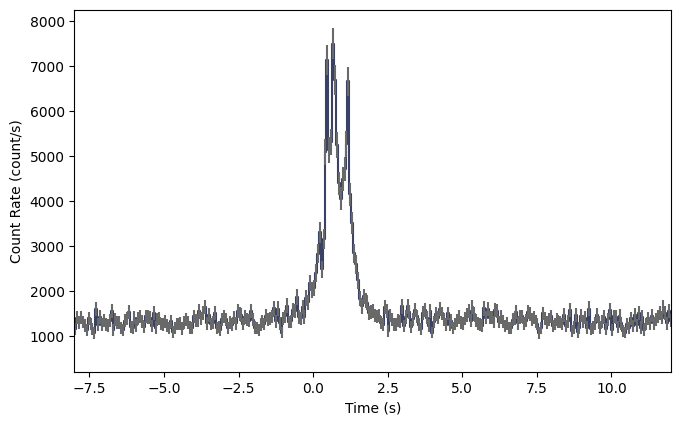

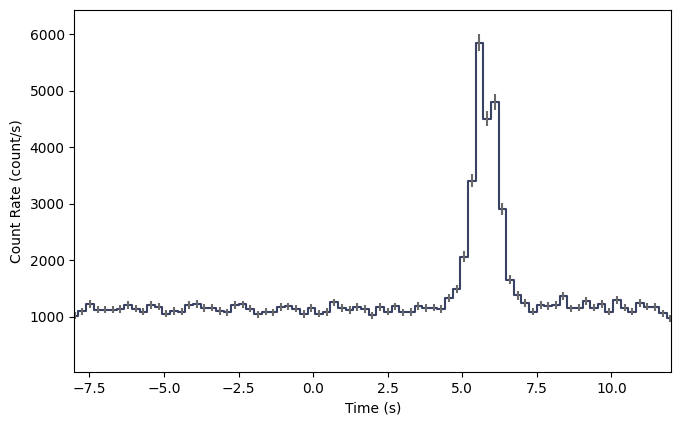

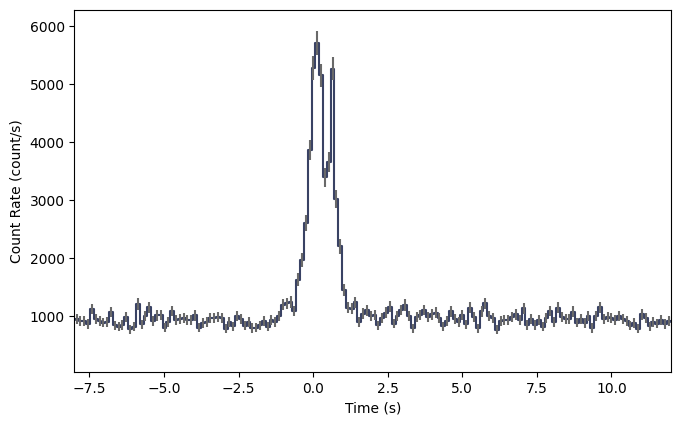

In [3]:
import matplotlib.pyplot as plt 

# plot the data
phaiis = [phaii1, phaii2, phaii3]
lcplots = [Lightcurve(p.to_lightcurve()) for p in phaiis]
for lcplot in lcplots:
    lcplot.xlim = -8, 12
plt.show()

## The Source Interval and Required Data Length

For this tutorial, we will use the Chi2-like statistic described in Pal'shin et al., 2013, which requires defining a source selection for each lightcurve. All source intervals should be approximately equal duration. 

Beyond defining source intervals, the lightcurves must contain sufficient data to accomodate all required time shifts. In most cases, the maximum number of shifts is determined by the light-travel-time between the observing instruments, although you may also specify a maximum shift manually (see below).

Regardless of how the maximum shift is chosen, the algorithm imposes the following constraints: the lightcurve with the highest time resolution must extend at least `max_offset` seconds **before** the start of the source interval of the lower-resolution lightcurve, and at least `max_offset` seconds **after** the end of that interval.

As an example, consider our first two lightcurves. Supppose the maximum light-travel time is 10 s. We select a source interval of (-2., 3.) s for Lightcurve 1 and (3, 8) for Lightcurve 2. Since Lightcurve 2 has the lower time resolution, it serves as the reference lightcurve. Consequentially, Lightcurve 1 must contain continuous data from T0 - 7 s to T0 + 18 s to satify the time-shift requirements.

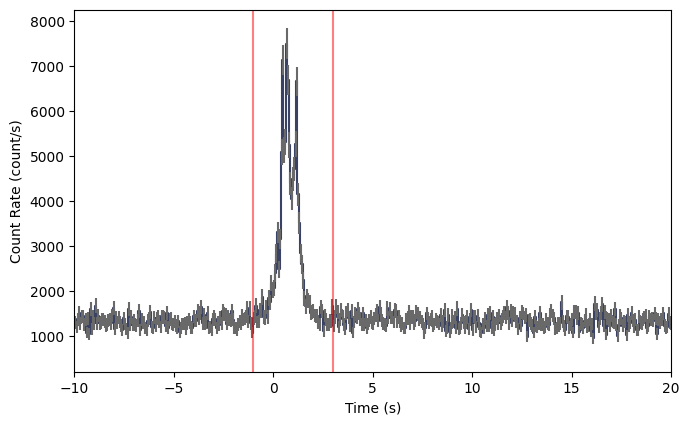

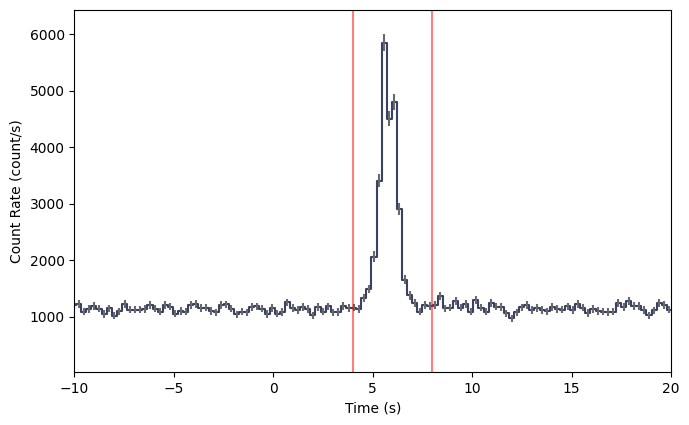

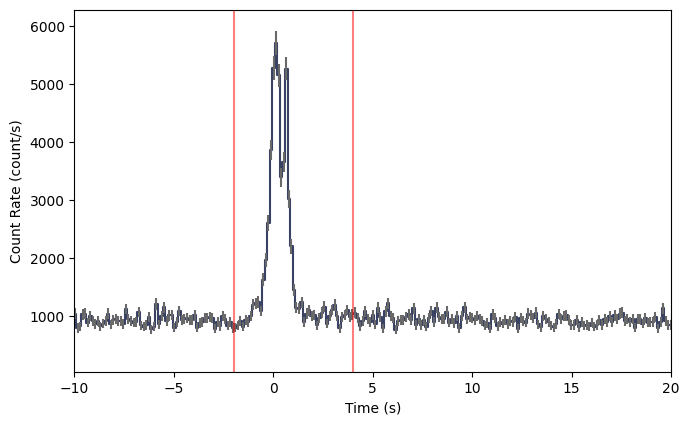

In [4]:
# define the source intervals
src1 = (-1., 3)
src2 = (4., 8.)
src3 = (-2., 4.)
srcs = [src1, src2, src3]

# plot the data with the source selections
phaiis = [phaii1, phaii2, phaii3]

lcplots = [Lightcurve(p.to_lightcurve()) for p in phaiis]
for lcplot, src in zip(lcplots, srcs):
    lcplot.xlim = -10, 20
    lcplot.ax.axvline(x=src[0], color='red', alpha=0.5)
    lcplot.ax.axvline(x=src[1], color='red', alpha=0.5)
plt.show()

### Fit the Background

Now we fit the background as shown in the last tutorial.

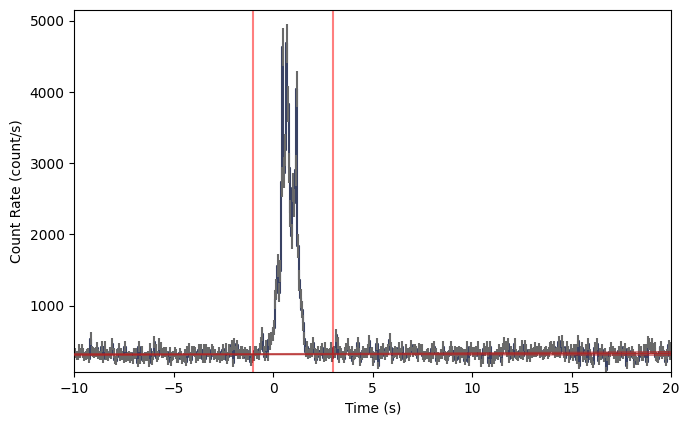

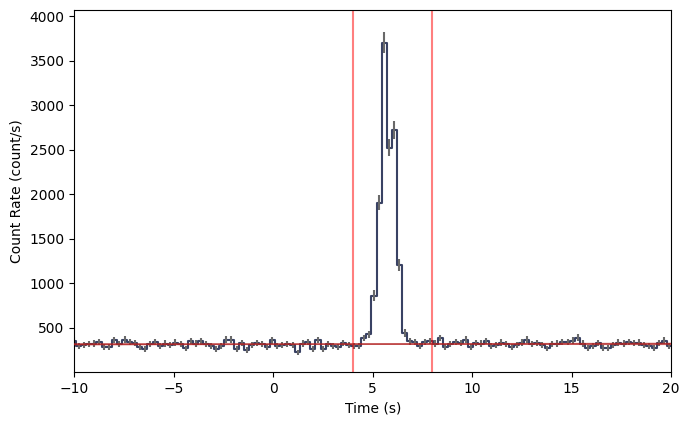

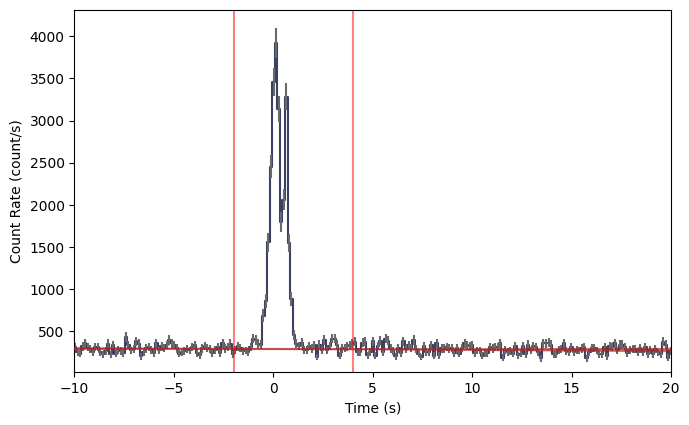

In [5]:
from gdt.core.background.fitter import BackgroundFitter
from gdt.core.background.binned import Polynomial

# define the energy range
energy_range = (50.0, 300.0)

# initialize the background fitter with the data and background selections
bkgd_fitter1 = BackgroundFitter.from_phaii(phaii1, Polynomial, [(-9.0, -3.0), (7.0, 11.0)])
bkgd_fitter1.fit(order=1)
bkgd_model1 = bkgd_fitter1.interpolate_bins(phaii1.data.tstart, phaii1.data.tstop)

# fit the background of the second lightcurve
bkgd_fitter2 = BackgroundFitter.from_phaii(phaii2, Polynomial, [(-9.0, 0.), (10.0, 18.0)])
bkgd_fitter2.fit(order=1)
bkgd_model2 = bkgd_fitter2.interpolate_bins(phaii2.data.tstart, phaii2.data.tstop)

# fit the background of the third lightcurve
bkgd_fitter3 = BackgroundFitter.from_phaii(phaii3, Polynomial, [(-9.0, -3.0), (7.0, 11.0)])
bkgd_fitter3.fit(order=1)
bkgd_model3 = bkgd_fitter3.interpolate_bins(phaii3.data.tstart, phaii3.data.tstop)

# plot the lightcurves
bkgd_fitters = [bkgd_fitter1, bkgd_fitter2, bkgd_fitter3]
bkgd_models = [bkgd_model1, bkgd_model2, bkgd_model3]

lcplots = [Lightcurve(data=phaii.to_lightcurve(energy_range=energy_range), 
                     background=bkgd_model.integrate_energy(*energy_range))
                     for phaii, bkgd_model in zip(phaiis, bkgd_models)]
for lcplot, src in zip(lcplots, srcs):
    lcplot.xlim = -10, 20
    lcplot.ax.axvline(x=src[0], color='red', alpha=0.5)
    lcplot.ax.axvline(x=src[1], color='red', alpha=0.5)
plt.show()

In [6]:
from gdt.ipn.instrument import *

# store the lightcurves and background as observations
observations = [Observation(phaii.to_lightcurve(energy_range=energy_range),
                    background=bkgd_model.integrate_energy(*energy_range))
                        for phaii, bkgd_model in zip(phaiis, bkgd_models)]

# match the spacecraft to the observation
scpos1 = SpacecraftPosition.from_distance(500.0, 0.0)
scpos2 = SpacecraftPosition.from_distance(2e5, 0.0)
scpos3 = SpacecraftPosition.from_vectors([350.0, -200.0, 350.0], [0.0, 0.0, 0.0])

spacecraft1 = Spacecraft(scpos1)
spacecraft2 = Spacecraft(scpos2)
spacecraft3 = Spacecraft(scpos3)
spacecraft = [spacecraft1, spacecraft2, spacecraft3]
_ = [spcft.set_observation(observation) for spcft, observation in zip(spacecraft,observations)]

## Find the time delays

Now we will calculate the time delays between pairs of our lightcurves. 

As previously mentioned, if you would like to manually set the maximum time offset, you can provide `ipn.localize` with the `max_dt` argument. We choose `max_dt=6` here. Note, if you consider too small a maximum time offset, the true offset may be excluded from the calculation, and if you consider too large an offset, then the calculation may take a longer time run (particularly for lightcurves with small time resolutions).

If you would like, you can also plot the lightcurves at each time shift by setting `plot=True`. But be careful! If 100 time shifts need to be calculated, 100 plots will be generated in the notebook below.

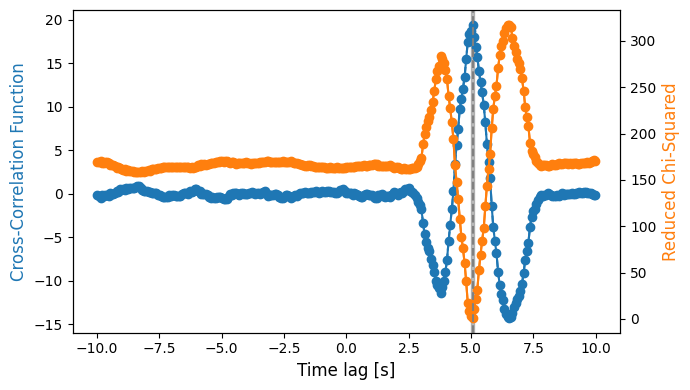

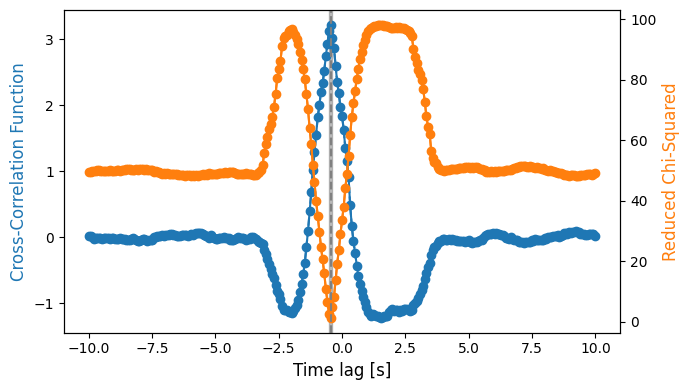

Time offset: 5.056 (+0.064, -0.064)
Time offset: -0.448 (+0.064, -0.064)


In [7]:
from gdt.ipn.algorithms.ccf import Ipn

# initialize the IPN with the lightcurve observations
ipn1 = Ipn.from_list([spacecraft1, spacecraft2]) # lightcurve 1 and lightcurve 2
ipn2 = Ipn.from_list([spacecraft1, spacecraft3]) # lightcurve 1 and lightcurve 3

# perform the time shifts
ipn1.localize(src1, src2, max_dt=10., plot=False)
ipn2.localize(src1, src3, max_dt=10., plot=False)

# plot the fit of the CCF and chisq for each time shift
ipn1.plot_fit()
ipn2.plot_fit()

# the time offset and error
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn1.time_offset.dt, ipn1.time_offset.err[1], ipn1.time_offset.err[0]))
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn2.time_offset.dt, ipn2.time_offset.err[1], ipn2.time_offset.err[0]))

Nice! For our first pair of lightcurves, we received a time offset very close to the true offset of +5 s. For our second pair of lightcurves, the true offset lies within the 3 sigma confidence intervals.

Now, if desired you can create localizations using the time offsets, as demonstrated in the last tutorial.